In [1]:
include("../LiPoSID.jl")
using QuantumOptics
basis = NLevelBasis(2)
using LinearAlgebra
using HDF5
using DynamicPolynomials
using Dates
using TSSOS
using DifferentialEquations
using Statistics
using Printf

## Markovian vs Non-Markovian Kossakowski: comparison on `ALL_GAMMAS_B4_D10.h5`

Both models are identified from the same four basis-state training trajectories
and tested on the same ten dodecahedron states.

**Markovian** (`Hm = 0`, `Cm = 0`, memory lag `k = 0`):
$$\dot\rho = \mathcal{L}(H,C)\,\rho$$

**Non-Markovian** (shared `H`, independent `Cm`, memory lag `k`):
$$\dot\rho(t) = \mathcal{L}(H,C)\,\rho(t) + \mathcal{L}(H,C_m)\,\rho(t - k\Delta t)$$

In [2]:
# Kossakowski orthonormal basis: f_i = σ_i / 2
σˣ = [ 0 1;  1 0 ]
σʸ = [ 0.   im; -im  0. ]
σᶻ = [ 1.  0;   0  -1. ]
fᴷ₁ = σˣ / 2;  fᴷ₂ = σʸ / 2;  fᴷ₃ = σᶻ / 2
@assert tr(fᴷ₁ * fᴷ₂) ≈ 0 && tr(fᴷ₁ * fᴷ₃) ≈ 0 && tr(fᴷ₂ * fᴷ₃) ≈ 0
@assert tr(fᴷ₁ * fᴷ₁) ≈ 1/2 && tr(fᴷ₂ * fᴷ₂) ≈ 1/2 && tr(fᴷ₃ * fᴷ₃) ≈ 1/2
fᴷᴼᴺᴮ = [fᴷ₁, fᴷ₂, fᴷ₃]

3-element Vector{Matrix{ComplexF64}}:
 [0.0 + 0.0im 0.5 + 0.0im; 0.5 + 0.0im 0.0 + 0.0im]
 [0.0 + 0.0im 0.0 + 0.5im; 0.0 - 0.5im 0.0 + 0.0im]
 [0.5 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im -0.5 + 0.0im]

In [3]:
"""Kossakowski RHS: -i[H,ρ] + (1/2) Σᵢⱼ Cᵢⱼ (2fᵢρfⱼ† - ρfⱼ†fᵢ - fⱼ†fᵢρ)"""
function kossak_rhs(ρ, H, C, Fᴼᴺᴮ)
    U = (H * ρ - ρ * H) / im
    D = sum(C .* [2*fᵢ*ρ*fⱼ' - ρ*fⱼ'*fᵢ - fⱼ'*fᵢ*ρ for fᵢ in Fᴼᴺᴮ, fⱼ in Fᴼᴺᴮ]) / 2
    return U + D
end

kossak_rhs

In [4]:
"""
Non-Markovian Kossakowski objective (Simpson quadrature).
Pass Hm=zeros(2,2), Cm=zeros(3,3), k=0 for the pure Markovian case.
"""
function non_mark_kossak_obj(ρ, t, H, C, Hm, Cm, k)
    obj = 0
    for i in (k+3):length(ρ)
        ρ_avg = (ρ[i-2]   + 4ρ[i-1]   + ρ[i])   / 3
        ρ_mem = (ρ[i-k-2] + 4ρ[i-k-1] + ρ[i-k]) / 3
        residual = ρ[i] - ρ[i-2] -
                   (t[i]-t[i-1]) * kossak_rhs(ρ_avg, H,  C,  fᴷᴼᴺᴮ) -
                   (t[i]-t[i-1]) * kossak_rhs(ρ_mem, Hm, Cm, fᴷᴼᴺᴮ)
        obj += LiPoSID.frobenius_norm2(residual)
    end
    if isempty(monomials(obj))
        obj = 0.
    else
        obj = sum(real(coef) * mon for (coef, mon) in zip(coefficients(obj), monomials(obj)))
    end
    return obj
end

non_mark_kossak_obj

In [5]:
"""Simulate non-Markovian Kossakowski dynamics (ODE solver, fixed step).
Pass Hm=zeros(2,2), Cm=zeros(3,3), k=0 for the pure Markovian case."""
function simulate_nonmark_kossak(ρ₀, t, H, C, Hm, Cm, k)
    ρ = Vector{Matrix{ComplexF64}}(undef, length(t))
    ρ[1] = ρ₀
    for i in 2:length(t)
        Δt    = t[i] - t[i-1]
        i_mem = max(1, i - k)
        Lm    = kossak_rhs(ρ[i_mem], Hm, Cm, fᴷᴼᴺᴮ)
        function matrix_ode!(dρ, ρ_c, p, t)
            dρ .= kossak_rhs(ρ_c, H, C, fᴷᴼᴺᴮ) + Lm
        end
        prob = ODEProblem(matrix_ode!, ρ[i-1], (t[i-1], t[i]))
        sol  = solve(prob, dt=Δt, adaptive=false)
        ρ[i] = sol.u[end]
    end
    return ρ
end

simulate_nonmark_kossak

In [6]:
"""Constrained sparse SOS optimisation via TSSOS."""
function cs_tssos_opt(obj::Polynomial, constr::Vector{<:Polynomial})
    all_vars    = union(variables(obj), reduce(union, variables.(constr)))
    solution    = variables(obj) => nothing
    opt_val     = nothing
    status      = :Error
    relax_order = maxdegree(obj) > 2 ? maxdegree(obj) : 2
    try
        redirect_stdout(open("/dev/null", "w")) do
            redirect_stderr(open("/dev/null", "w")) do
                opt, sol, data = TSSOS.cs_tssos_first(
                    [obj; constr...], all_vars, relax_order;
                    numeq=0, solution=true, QUIET=true)
                prev_opt, prev_sol, prev_data = opt, sol, data
                while sol !== nothing
                    prev_opt, prev_sol, prev_data = opt, sol, data
                    opt, sol, data = TSSOS.cs_tssos_higher!(data; QUIET=true, solution=true)
                end
                ref_sol, flag = TSSOS.refine_sol(prev_opt, prev_sol, prev_data;
                                                 QUIET=true, tol=1e-10)
                solution = variables(obj) => ref_sol
                opt_val  = prev_opt
                status   = flag == 0 ? :Global : :Local
            end
        end
    catch e
        println("TSSOS failed: ", e)
    end
    return solution, opt_val, status
end

cs_tssos_opt

In [7]:
"""Read density matrix time series from ALL_GAMMAS_B4_D10.h5 format.
HDF5 structure: file[state][γ_string] → {t, p0, s_re, s_im}"""
function read_timeevolution(file_name, state, γ)
    h5open(file_name, "r") do file
        ρᵧ     = read(file[state][string(γ)])
        t      = ρᵧ["t"]
        ρ₀₀    = ρᵧ["p0"]
        Re_ρ₀₁ = ρᵧ["s_re"]
        Im_ρ₀₁ = ρᵧ["s_im"]
        n = length(t)
        ρ_series = Vector{Matrix{ComplexF64}}(undef, n)
        t_series = Vector{Float64}(undef, n)
        for i in 1:n
            ρ_series[i] = convert(Matrix{ComplexF64},
                [ ρ₀₀[i]                     Re_ρ₀₁[i] + im*Im_ρ₀₁[i]
                  Re_ρ₀₁[i] - im*Im_ρ₀₁[i]  1 - ρ₀₀[i]               ])
            t_series[i] = convert(Float64, t[i])
        end
        return t_series, ρ_series
    end
end

read_timeevolution

In [8]:
subs_cmat(mat, sol) = map(mat) do e
    v = subs(e, sol)
    try; convert(ComplexF64, v); catch; 0.0+0im; end
end

"""Project matrix to nearest valid density matrix: Hermitian, PSD, trace-1."""
function to_density_op(basis, ρ)
    ρh   = Hermitian((ρ + ρ') / 2)
    F    = eigen(ρh)
    vals = max.(real(F.values), 0.0)
    s    = sum(vals);  s > 0 && (vals ./= s)
    DenseOperator(basis, Matrix(Hermitian(F.vectors * Diagonal(vals) * F.vectors')))
end

to_density_op

In [11]:
# ── Hamiltonian (shared by both models) ──────────────────────────────────────
@polyvar ϵ h_Re h_Im
H0ˢʸᵐᵇ = [ ϵ               h_Re + im*h_Im
            h_Re - im*h_Im  -ϵ             ] / 2

# ── Current Kossakowski matrix C ─────────────────────────────────────────────
@polyvar γ[1:3] a[1:3]
κ₁ = -γ[1]+γ[2]+γ[3];  κ₂ = γ[1]-γ[2]+γ[3];  κ₃ = γ[1]+γ[2]-γ[3]
Cˢʸᵐᵇ = [ κ₁        -im*a[3]   im*a[2]
           im*a[3]    κ₂       -im*a[1]
          -im*a[2]    im*a[1]   κ₃      ]
c_constr1 = γ[1]+γ[2]+γ[3]
c_constr2 = κ₁*κ₂ + κ₂*κ₃ + κ₃*κ₁ - a[1]^2 - a[2]^2 - a[3]^2
c_constr3 = κ₁*κ₂*κ₃ - κ₁*a[1]^2 - κ₂*a[2]^2 - κ₃*a[3]^2
mark_constraints = [γ[1], γ[2], γ[3], c_constr1, c_constr2, c_constr3]

# ── Memory Kossakowski matrix Cm (non-Markovian only) ────────────────────────
@polyvar γm[1:3] am[1:3]
κm₁ = -γm[1]+γm[2]+γm[3];  κm₂ = γm[1]-γm[2]+γm[3];  κm₃ = γm[1]+γm[2]-γm[3]
Cmˢʸᵐᵇ = [ κm₁        -im*am[3]   im*am[2]
            im*am[3]    κm₂       -im*am[1]
           -im*am[2]    im*am[1]   κm₃      ]
cm_constr1 = γm[1]+γm[2]+γm[3]
cm_constr2 = κm₁*κm₂ + κm₂*κm₃ + κm₃*κm₁ - am[1]^2 - am[2]^2 - am[3]^2
cm_constr3 = κm₁*κm₂*κm₃ - κm₁*am[1]^2 - κm₂*am[2]^2 - κm₃*am[3]^2
nonmark_constraints = vcat(mark_constraints, [γm[1], γm[2], γm[3], cm_constr1, cm_constr2, cm_constr3])

12-element Vector{Polynomial{true, Int64}}:
 γ₁
 γ₂
 γ₃
 γ₁ + γ₂ + γ₃
 -γ₁² + 2γ₁γ₂ + 2γ₁γ₃ - γ₂² + 2γ₂γ₃ - γ₃² - a₁² - a₂² - a₃²
 -γ₁³ + γ₁²γ₂ + γ₁²γ₃ + γ₁γ₂² - 2γ₁γ₂γ₃ + γ₁γ₃² + γ₁a₁² - γ₁a₂² - γ₁a₃² - γ₂³ + γ₂²γ₃ + γ₂γ₃² - γ₂a₁² + γ₂a₂² - γ₂a₃² - γ₃³ - γ₃a₁² - γ₃a₂² + γ₃a₃²
 γm₁
 γm₂
 γm₃
 γm₁ + γm₂ + γm₃
 -γm₁² + 2γm₁γm₂ + 2γm₁γm₃ - γm₂² + 2γm₂γm₃ - γm₃² - am₁² - am₂² - am₃²
 -γm₁³ + γm₁²γm₂ + γm₁²γm₃ + γm₁γm₂² - 2γm₁γm₂γm₃ + γm₁γm₃² + γm₁am₁² - γm₁am₂² - γm₁am₃² - γm₂³ + γm₂²γm₃ + γm₂γm₃² - γm₂am₁² + γm₂am₂² - γm₂am₃² - γm₃³ - γm₃am₁² - γm₃am₂² + γm₃am₃²

In [37]:
data_file    = "../DATA/ALL_GAMMAS_B4_D10.h5"
tests_dir    = "../TESTS/"

train_states = ["B"*string(n) for n=1:4]
test_states  = ["D"*string(n) for n=1:10]

k = 10   # memory lag (steps) for the non-Markovian model

γ_values = ["0.079477", "0.25133", "0.79477", "2.5133", "7.9477", "25.133", "79.477", "251.33"]

date_str = string(Dates.format(now(), "yyyy-u-dd_at_HH-MM"))
out_file = tests_dir * "Mark_vs_NonMark_k$(k)_ALLGAMMA_" * date_str * ".h5"
println("Output: ", out_file)

Output: ../TESTS/Mark_vs_NonMark_k10_ALLGAMMA_2026-Apr-14_at_17-51.h5


In [38]:
F_mark_mean    = Dict{String,Float64}()
F_nonmark_mean = Dict{String,Float64}()

for γᵢ in γ_values
    println("\n══ γ = ", γᵢ, " ══")

    # ── Build training objectives ─────────────────────────────────────────
    obj_mark    = 0
    obj_nonmark = 0
    for state in train_states
        t_trn, ρ_trn = read_timeevolution(data_file, state, γᵢ)
        obj_mark    += non_mark_kossak_obj(ρ_trn, t_trn, H0ˢʸᵐᵇ, Cˢʸᵐᵇ, zeros(2,2), zeros(3,3), 1)
        #obj_nonmark += non_mark_kossak_obj(ρ_trn, t_trn, H0ˢʸᵐᵇ, Cˢʸᵐᵇ, H0ˢʸᵐᵇ,    Cmˢʸᵐᵇ,    k)
        obj_nonmark += non_mark_kossak_obj(ρ_trn, t_trn, H0ˢʸᵐᵇ, Cˢʸᵐᵇ, zeros(2,2),    Cmˢʸᵐᵇ,    k)
    end

    # ── Markovian identification ──────────────────────────────────────────
    sol_m, opt_m, stat_m = cs_tssos_opt(obj_mark, mark_constraints)
    H_m = subs_cmat(H0ˢʸᵐᵇ, sol_m)
    C_m = subs_cmat(Cˢʸᵐᵇ,  sol_m)
    @printf("  Markovian   : status=%-8s opt=%.4e\n", stat_m, opt_m)

    # ── Non-Markovian identification ──────────────────────────────────────
    sol_nm, opt_nm, stat_nm = cs_tssos_opt(obj_nonmark, nonmark_constraints)
    H_nm  = subs_cmat(H0ˢʸᵐᵇ, sol_nm)
    C_nm  = subs_cmat(Cˢʸᵐᵇ,  sol_nm)
    Cm_nm = subs_cmat(Cmˢʸᵐᵇ, sol_nm)
    @printf("  NonMark k=%-2d: status=%-8s opt=%.4e\n", k, stat_nm, opt_nm)

    # ── Save identified parameters ────────────────────────────────────────
    h5open(out_file, "cw") do fid
        gm  = create_group(fid, "gamma_$(γᵢ)/markovian")
        gm["H"] = H_m;  gm["C"] = C_m
        gnm = create_group(fid, "gamma_$(γᵢ)/nonmarkovian")
        gnm["H"] = H_nm;  gnm["C"] = C_nm;  gnm["Cm"] = Cm_nm;  gnm["k"] = k
    end

    # ── Test on all test states ───────────────────────────────────────────
    Fm_all = Float64[];  Fnm_all = Float64[]
    for state in test_states
        t_tst, ρ_tst = read_timeevolution(data_file, state, γᵢ)

        # k=1 for Markovian simulation: Cm=zeros so memory term is always 0;
        # k=1 keeps i_mem=i-1 which is always a computed step (k=0 would read ρ[i] before it's written)
        ρ_sim_m  = simulate_nonmark_kossak(ρ_tst[1], t_tst, H_m,  C_m,  zeros(2,2), zeros(3,3), 1)
        #ρ_sim_nm = simulate_nonmark_kossak(ρ_tst[1], t_tst, H_nm, C_nm, H_nm,       Cm_nm,      k)
        ρ_sim_nm = simulate_nonmark_kossak(ρ_tst[1], t_tst, H_nm, C_nm, zeros(2,2),  Cm_nm,      k)

        ρ_exact      = [DenseOperator(basis, Hermitian(ρ)) for ρ in ρ_tst]
        ρ_sim_m_ops  = [to_density_op(basis, ρ) for ρ in ρ_sim_m]
        ρ_sim_nm_ops = [to_density_op(basis, ρ) for ρ in ρ_sim_nm]

        Fm  = Float64[abs(fidelity(ρ₁, ρ₂)) for (ρ₁, ρ₂) in zip(ρ_exact, ρ_sim_m_ops)]
        Fnm = Float64[abs(fidelity(ρ₁, ρ₂)) for (ρ₁, ρ₂) in zip(ρ_exact, ρ_sim_nm_ops)]

        append!(Fm_all, Fm);  append!(Fnm_all, Fnm)

        h5open(out_file, "cw") do fid
            create_group(fid, "gamma_$(γᵢ)/markovian/$(state)")[   "Fidelity"] = Fm
            create_group(fid, "gamma_$(γᵢ)/nonmarkovian/$(state)")["Fidelity"] = Fnm
        end

        @printf("    %s  F̄_M=%.4f  F̄_NM=%.4f  ΔF̄=%+.4f\n",
                state, mean(Fm), mean(Fnm), mean(Fnm)-mean(Fm))
    end

    F_mark_mean[γᵢ]    = mean(Fm_all)
    F_nonmark_mean[γᵢ] = mean(Fnm_all)

    @printf("  ─── γ=%-8s  F̄_Mark=%.6f  F̄_NonMark=%.6f  Δ=%+.2e\n",
            γᵢ, F_mark_mean[γᵢ], F_nonmark_mean[γᵢ],
            F_nonmark_mean[γᵢ] - F_mark_mean[γᵢ])
end

println("\nDone → ", out_file)


══ γ = 0.079477 ══
  Markovian   : status=Local    opt=2.1878e-04
  NonMark k=10: status=Local    opt=4.2851e-05
    D1  F̄_M=0.9952  F̄_NM=0.9958  ΔF̄=+0.0006
    D2  F̄_M=0.9953  F̄_NM=0.9958  ΔF̄=+0.0006
    D3  F̄_M=0.9994  F̄_NM=0.9995  ΔF̄=+0.0000
    D4  F̄_M=0.9994  F̄_NM=0.9995  ΔF̄=+0.0000
    D5  F̄_M=0.9970  F̄_NM=0.9974  ΔF̄=+0.0004
    D6  F̄_M=0.9970  F̄_NM=0.9974  ΔF̄=+0.0004
    D7  F̄_M=0.9984  F̄_NM=0.9986  ΔF̄=+0.0002
    D8  F̄_M=0.9984  F̄_NM=0.9986  ΔF̄=+0.0002
    D9  F̄_M=0.9897  F̄_NM=0.9906  ΔF̄=+0.0009
    D10  F̄_M=0.9999  F̄_NM=0.9999  ΔF̄=+0.0000
  ─── γ=0.079477  F̄_Mark=0.996978  F̄_NonMark=0.997302  Δ=+3.25e-04

══ γ = 0.25133 ══
  Markovian   : status=Local    opt=2.8468e-04
  NonMark k=10: status=Local    opt=6.2090e-05
    D1  F̄_M=0.9954  F̄_NM=0.9791  ΔF̄=-0.0164
    D2  F̄_M=0.9954  F̄_NM=0.9795  ΔF̄=-0.0159
    D3  F̄_M=0.9982  F̄_NM=0.9842  ΔF̄=-0.0140
    D4  F̄_M=0.9981  F̄_NM=0.9844  ΔF̄=-0.0138
    D5  F̄_M=0.9962  F̄_NM=0.9741  ΔF̄=-0.022

In [39]:
# ── Summary table ─────────────────────────────────────────────────────────────
println()
@printf("%-12s  %12s  %12s  %10s\n", "γ", "F̄ Markovian", "F̄ NonMark k=$k", "Δ F̄")
println(repeat("-", 52))
for γᵢ in γ_values
    Δ = F_nonmark_mean[γᵢ] - F_mark_mean[γᵢ]
    @printf("%-12s  %12.8f  %12.8f  %+10.2e\n",
            γᵢ, F_mark_mean[γᵢ], F_nonmark_mean[γᵢ], Δ)
end
println(repeat("-", 52))

# Save summary to HDF5
h5open(out_file, "cw") do fid
    fid["summary/gamma"]         = γ_values
    fid["summary/F_mark_mean"]   = [F_mark_mean[γ]    for γ in γ_values]
    fid["summary/F_nonmark_mean"] = [F_nonmark_mean[γ] for γ in γ_values]
    fid["summary/k"]             = k
end


γ              F̄ Markovian  F̄ NonMark k=10         Δ F̄
----------------------------------------------------
0.079477        0.99697769    0.99730219   +3.25e-04
0.25133         0.99665104    0.98138270   -1.53e-02
0.79477         0.99774088    0.99782004   +7.92e-05
2.5133          0.99908901    0.99916895   +7.99e-05
7.9477          0.99968870    0.99968105   -7.65e-06
25.133          0.99673648    0.99676235   +2.59e-05
79.477          0.99869796    0.99865023   -4.77e-05
251.33          0.99944292    0.99944860   +5.69e-06
----------------------------------------------------


10

In [35]:
# ── Summary table ─────────────────────────────────────────────────────────────
println()
@printf("%-12s  %12s  %12s  %10s\n", "γ", "F̄ Markovian", "F̄ NonMark k=$k", "Δ F̄")
println(repeat("-", 52))
for γᵢ in γ_values
    Δ = F_nonmark_mean[γᵢ] - F_mark_mean[γᵢ]
    @printf("%-12s  %12.8f  %12.8f  %+10.2e\n",
            γᵢ, F_mark_mean[γᵢ], F_nonmark_mean[γᵢ], Δ)
end
println(repeat("-", 52))

# Save summary to HDF5
h5open(out_file, "cw") do fid
    fid["summary/gamma"]         = γ_values
    fid["summary/F_mark_mean"]   = [F_mark_mean[γ]    for γ in γ_values]
    fid["summary/F_nonmark_mean"] = [F_nonmark_mean[γ] for γ in γ_values]
    fid["summary/k"]             = k
end


γ              F̄ Markovian  F̄ NonMark k=10         Δ F̄
----------------------------------------------------
0.079477        0.99697769    0.99730219   +3.25e-04
0.25133         0.99665104    0.98138270   -1.53e-02
0.79477         0.99774088    0.99782004   +7.92e-05
2.5133          0.99908901    0.99916895   +7.99e-05
7.9477          0.99968870    0.99968105   -7.65e-06
25.133          0.99673648    0.99676235   +2.59e-05
79.477          0.99869796    0.99865023   -4.77e-05
251.33          0.99944292    0.99944860   +5.69e-06
----------------------------------------------------


10

In [27]:
# ── Summary table ─────────────────────────────────────────────────────────────
println()
@printf("%-12s  %12s  %12s  %10s\n", "γ", "F̄ Markovian", "F̄ NonMark k=$k", "Δ F̄")
println(repeat("-", 52))
for γᵢ in γ_values
    Δ = F_nonmark_mean[γᵢ] - F_mark_mean[γᵢ]
    @printf("%-12s  %12.8f  %12.8f  %+10.2e\n",
            γᵢ, F_mark_mean[γᵢ], F_nonmark_mean[γᵢ], Δ)
end
println(repeat("-", 52))

# Save summary to HDF5
h5open(out_file, "cw") do fid
    fid["summary/gamma"]         = γ_values
    fid["summary/F_mark_mean"]   = [F_mark_mean[γ]    for γ in γ_values]
    fid["summary/F_nonmark_mean"] = [F_nonmark_mean[γ] for γ in γ_values]
    fid["summary/k"]             = k
end


γ              F̄ Markovian  F̄ NonMark k=5         Δ F̄
----------------------------------------------------
0.079477        0.99697769    0.94507274   -5.19e-02
0.25133         0.99665104    0.99668061   +2.96e-05
0.79477         0.99774088    0.99779084   +5.00e-05
2.5133          0.99908901    0.99909790   +8.89e-06
7.9477          0.99968870    0.99968155   -7.14e-06
25.133          0.99673648    0.99675190   +1.54e-05
79.477          0.99869796    0.99867663   -2.13e-05
251.33          0.99944292    0.99946219   +1.93e-05
----------------------------------------------------


5

In [23]:
# ── Summary table ─────────────────────────────────────────────────────────────
println()
@printf("%-12s  %12s  %12s  %10s\n", "γ", "F̄ Markovian", "F̄ NonMark k=$k", "Δ F̄")
println(repeat("-", 52))
for γᵢ in γ_values
    Δ = F_nonmark_mean[γᵢ] - F_mark_mean[γᵢ]
    @printf("%-12s  %12.8f  %12.8f  %+10.2e\n",
            γᵢ, F_mark_mean[γᵢ], F_nonmark_mean[γᵢ], Δ)
end
println(repeat("-", 52))

# Save summary to HDF5
h5open(out_file, "cw") do fid
    fid["summary/gamma"]         = γ_values
    fid["summary/F_mark_mean"]   = [F_mark_mean[γ]    for γ in γ_values]
    fid["summary/F_nonmark_mean"] = [F_nonmark_mean[γ] for γ in γ_values]
    fid["summary/k"]             = k
end


γ              F̄ Markovian  F̄ NonMark k=1         Δ F̄
----------------------------------------------------
0.079477        0.99697769    0.94745028   -4.95e-02
0.25133         0.99665104    0.98252873   -1.41e-02
0.79477         0.99774088    0.99460559   -3.14e-03
2.5133          0.99908901    0.99889152   -1.97e-04
7.9477          0.99968870    0.99967924   -9.46e-06
25.133          0.99673648    0.99673634   -1.43e-07
79.477          0.99869796    0.99869529   -2.67e-06
251.33          0.99944292    0.99944062   -2.30e-06
----------------------------------------------------


1

In [20]:
# ── Summary table ─────────────────────────────────────────────────────────────
println()
@printf("%-12s  %12s  %12s  %10s\n", "γ", "F̄ Markovian", "F̄ NonMark k=$k", "Δ F̄")
println(repeat("-", 52))
for γᵢ in γ_values
    Δ = F_nonmark_mean[γᵢ] - F_mark_mean[γᵢ]
    @printf("%-12s  %12.8f  %12.8f  %+10.2e\n",
            γᵢ, F_mark_mean[γᵢ], F_nonmark_mean[γᵢ], Δ)
end
println(repeat("-", 52))

# Save summary to HDF5
h5open(out_file, "cw") do fid
    fid["summary/gamma"]         = γ_values
    fid["summary/F_mark_mean"]   = [F_mark_mean[γ]    for γ in γ_values]
    fid["summary/F_nonmark_mean"] = [F_nonmark_mean[γ] for γ in γ_values]
    fid["summary/k"]             = k
end


γ              F̄ Markovian  F̄ NonMark k=5         Δ F̄
----------------------------------------------------
0.079477        0.99697769    0.94396658   -5.30e-02
0.25133         0.99665104    0.98243276   -1.42e-02
0.79477         0.99774088    0.99448805   -3.25e-03
2.5133          0.99908901    0.99888779   -2.01e-04
7.9477          0.99968870    0.99970767   +1.90e-05
25.133          0.99673648    0.99675533   +1.88e-05
79.477          0.99869796    0.99868992   -8.04e-06
251.33          0.99944292    0.99946621   +2.33e-05
----------------------------------------------------


5

In [30]:
using CairoMakie
CairoMakie.activate!(type = "png")  # inline display in Jupyter

# ── Load per-trajectory infidelity data from HDF5 output ─────────────────────
γ_floats = parse.(Float64, γ_values)

# log10(1-F) for each time point across all test states, per γ, per model
log_inf_mark    = Dict{String, Vector{Float64}}()
log_inf_nonmark = Dict{String, Vector{Float64}}()

h5open(out_file, "r") do fid
    for γᵢ in γ_values
        vals_m  = Float64[]
        vals_nm = Float64[]
        for state in test_states
            Fm  = read(fid["gamma_$(γᵢ)/markovian/$(state)/Fidelity"])
            Fnm = read(fid["gamma_$(γᵢ)/nonmarkovian/$(state)/Fidelity"])
            # clamp to avoid log(0); skip the first point (F=1 by construction)
            append!(vals_m,  log10.(clamp.(1 .- Fm[2:end],  1e-10, 1.0)))
            append!(vals_nm, log10.(clamp.(1 .- Fnm[2:end], 1e-10, 1.0)))
        end
        log_inf_mark[γᵢ]    = vals_m
        log_inf_nonmark[γᵢ] = vals_nm
    end
end
println("Data loaded for $(length(γ_values)) γ values, $(length(test_states)) test states each.")


Data loaded for 8 γ values, 10 test states each.


Saved: ../TESTS/Mark_vs_NonMark_k10_ALLGAMMA_2026-Apr-14_at_17-51_violin.pdf


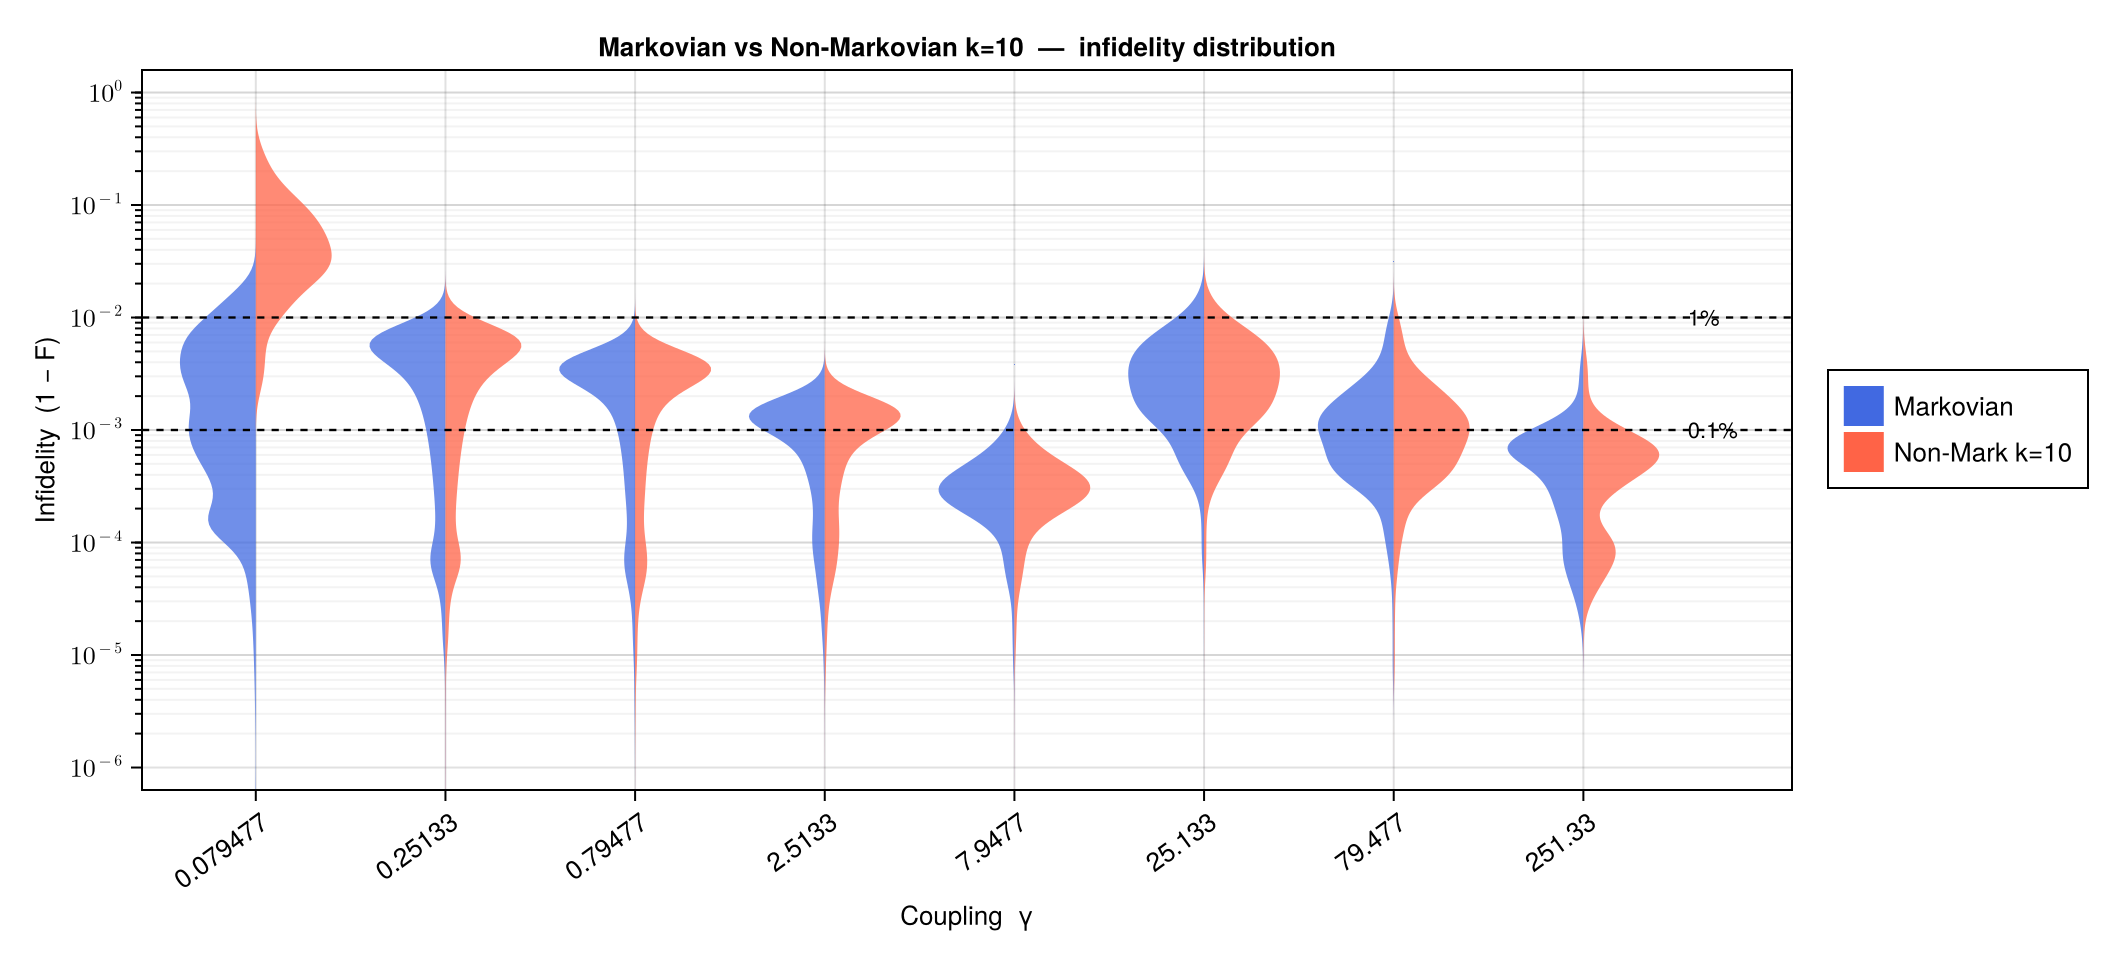

In [40]:
# ── Side-by-side violin plot: log infidelity per γ ───────────────────────────
# Left half of each violin = Markovian (blue), right half = Non-Markovian (red)

n = length(γ_values)
xs = 1:n   # integer positions on x axis

COLOR_M  = (:royalblue,   0.75)
COLOR_NM = (:tomato,      0.75)

fig = Figure(size=(180 + 110*n, 480), fontsize=13)
ax  = Axis(fig[1, 1],
    xlabel       = "Coupling  γ",
    ylabel       = "Infidelity  (1 − F)",
    title        = "Markovian vs Non-Markovian k=$k  —  infidelity distribution",
    xticks       = (xs, γ_values),
    xticklabelrotation = π/5,
)

for (i, γᵢ) in enumerate(γ_values)
    violin!(ax, fill(i, length(log_inf_mark[γᵢ])),    log_inf_mark[γᵢ];
            side=:left,  color=COLOR_M,  bandwidth=0.15, datalimits=(-10, 0))
    violin!(ax, fill(i, length(log_inf_nonmark[γᵢ])), log_inf_nonmark[γᵢ];
            side=:right, color=COLOR_NM, bandwidth=0.15, datalimits=(-10, 0))
end

# y axis: log scale ticks from 10^-6 to 10^0
ymin, ymax = -6.2, 0.2
ylims!(ax, ymin, ymax)
major_ticks  = collect(-6:0)
minor_ticks  = [log10(x) for p in -6:-1 for x in range(10.0^p, 10.0^(p+1); length=10)[2:end]]
ax.yticks    = (major_ticks, [L"10^{%$p}" for p in major_ticks])
ax.yminorticks = minor_ticks
ax.yminorgridvisible = true
ax.yminorticksvisible = true

# Reference lines at 1 % and 0.1 % infidelity
for (level, label) in [(0.01, "1%"), (0.001, "0.1%")]
    hlines!(ax, log10(level); color=:black, linestyle=:dash, linewidth=1.2)
    text!(ax, n + 0.55, log10(level); text=label, fontsize=11, align=(:left, :center))
end

xlims!(ax, 0.4, n + 1.1)

# Legend
elem_m  = [PolyElement(color=COLOR_M[1],  strokecolor=:transparent)]
elem_nm = [PolyElement(color=COLOR_NM[1], strokecolor=:transparent)]
Legend(fig[1, 2], [elem_m, elem_nm], ["Markovian", "Non-Mark k=$k"],
       framevisible=true, padding=(8,8,8,8))

violin_path = replace(out_file, ".h5" => "_violin.pdf")
save(violin_path, fig)
println("Saved: ", violin_path)
fig

Saved: ../TESTS/Mark_vs_NonMark_H0_k5_ALLGAMMA_2026-Apr-14_at_12-12_violin.pdf


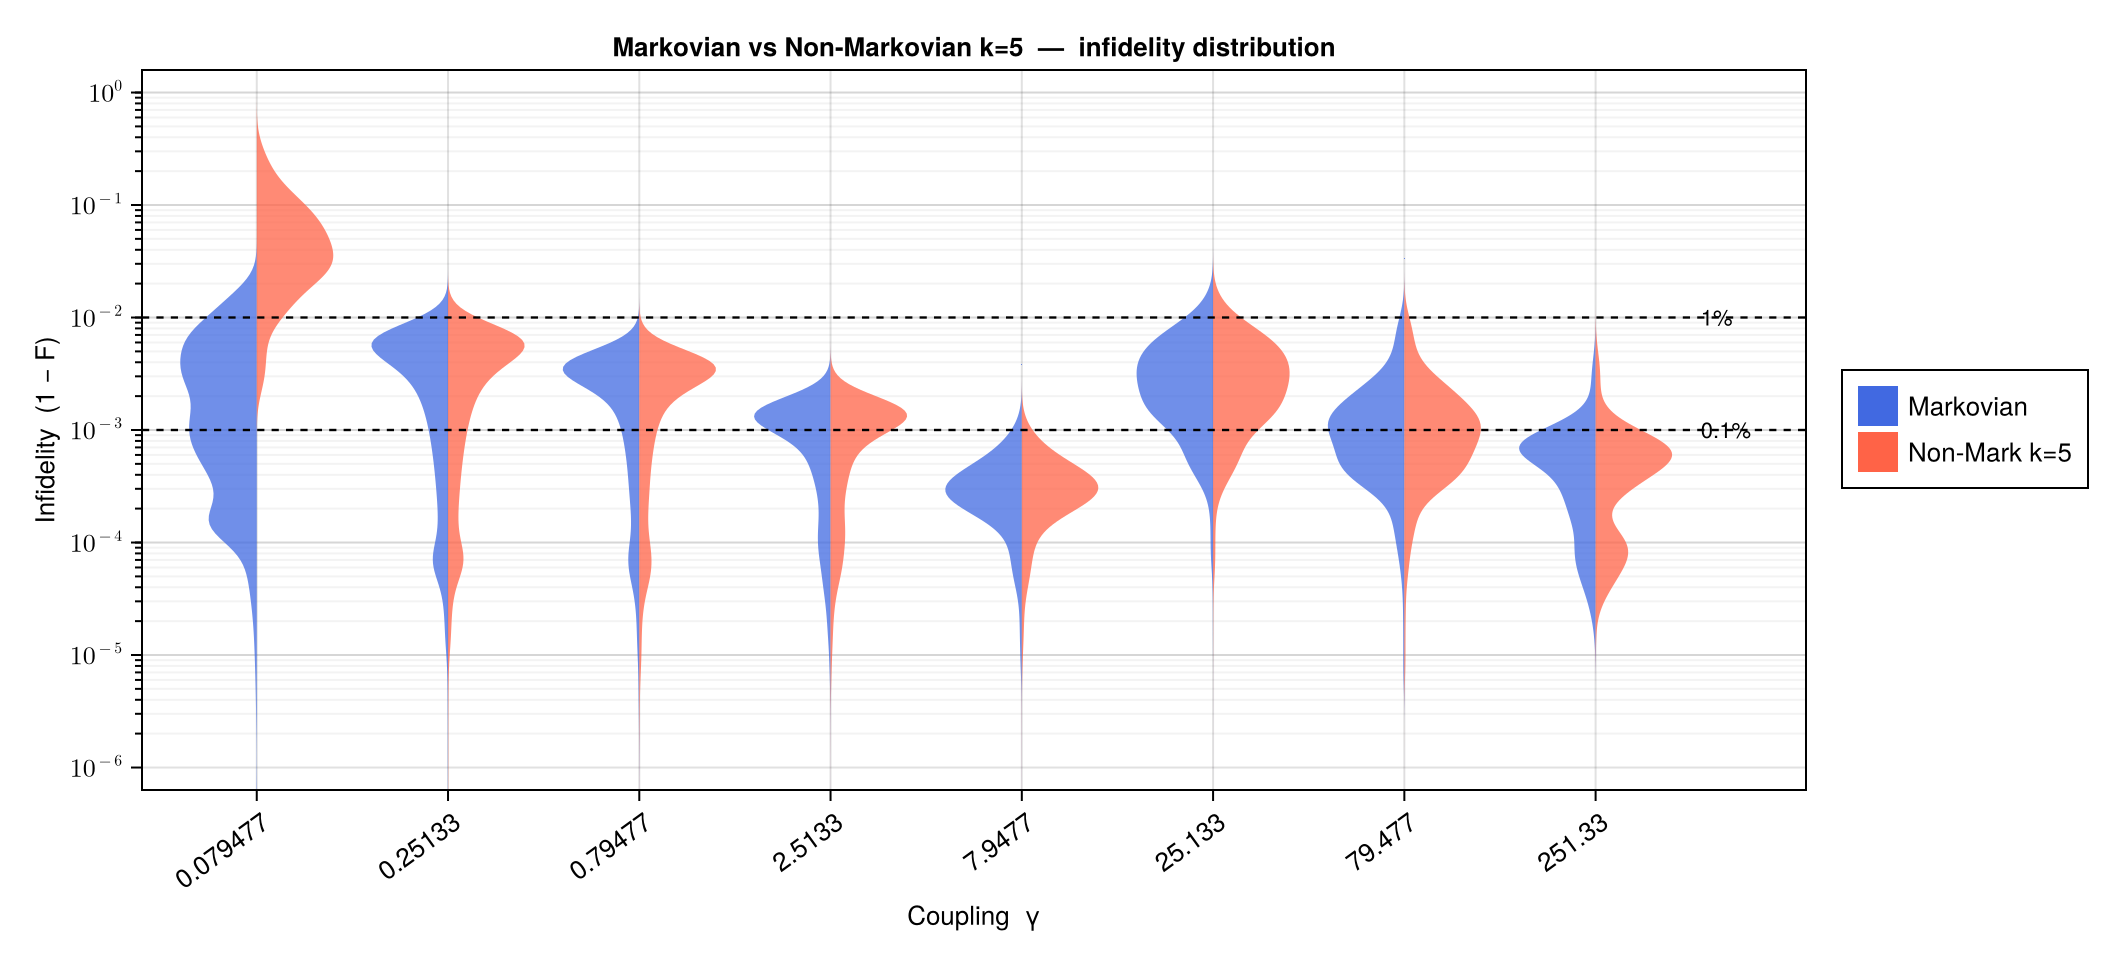

In [31]:
# ── Side-by-side violin plot: log infidelity per γ ───────────────────────────
# Left half of each violin = Markovian (blue), right half = Non-Markovian (red)

n = length(γ_values)
xs = 1:n   # integer positions on x axis

COLOR_M  = (:royalblue,   0.75)
COLOR_NM = (:tomato,      0.75)

fig = Figure(size=(180 + 110*n, 480), fontsize=13)
ax  = Axis(fig[1, 1],
    xlabel       = "Coupling  γ",
    ylabel       = "Infidelity  (1 − F)",
    title        = "Markovian vs Non-Markovian k=$k  —  infidelity distribution",
    xticks       = (xs, γ_values),
    xticklabelrotation = π/5,
)

for (i, γᵢ) in enumerate(γ_values)
    violin!(ax, fill(i, length(log_inf_mark[γᵢ])),    log_inf_mark[γᵢ];
            side=:left,  color=COLOR_M,  bandwidth=0.15, datalimits=(-10, 0))
    violin!(ax, fill(i, length(log_inf_nonmark[γᵢ])), log_inf_nonmark[γᵢ];
            side=:right, color=COLOR_NM, bandwidth=0.15, datalimits=(-10, 0))
end

# y axis: log scale ticks from 10^-6 to 10^0
ymin, ymax = -6.2, 0.2
ylims!(ax, ymin, ymax)
major_ticks  = collect(-6:0)
minor_ticks  = [log10(x) for p in -6:-1 for x in range(10.0^p, 10.0^(p+1); length=10)[2:end]]
ax.yticks    = (major_ticks, [L"10^{%$p}" for p in major_ticks])
ax.yminorticks = minor_ticks
ax.yminorgridvisible = true
ax.yminorticksvisible = true

# Reference lines at 1 % and 0.1 % infidelity
for (level, label) in [(0.01, "1%"), (0.001, "0.1%")]
    hlines!(ax, log10(level); color=:black, linestyle=:dash, linewidth=1.2)
    text!(ax, n + 0.55, log10(level); text=label, fontsize=11, align=(:left, :center))
end

xlims!(ax, 0.4, n + 1.1)

# Legend
elem_m  = [PolyElement(color=COLOR_M[1],  strokecolor=:transparent)]
elem_nm = [PolyElement(color=COLOR_NM[1], strokecolor=:transparent)]
Legend(fig[1, 2], [elem_m, elem_nm], ["Markovian", "Non-Mark k=$k"],
       framevisible=true, padding=(8,8,8,8))

violin_path = replace(out_file, ".h5" => "_violin.pdf")
save(violin_path, fig)
println("Saved: ", violin_path)
fig

Saved: ../TESTS/Mark_vs_NonMark_H0_k10_ALLGAMMA_2026-Apr-14_at_17-17_violin.pdf


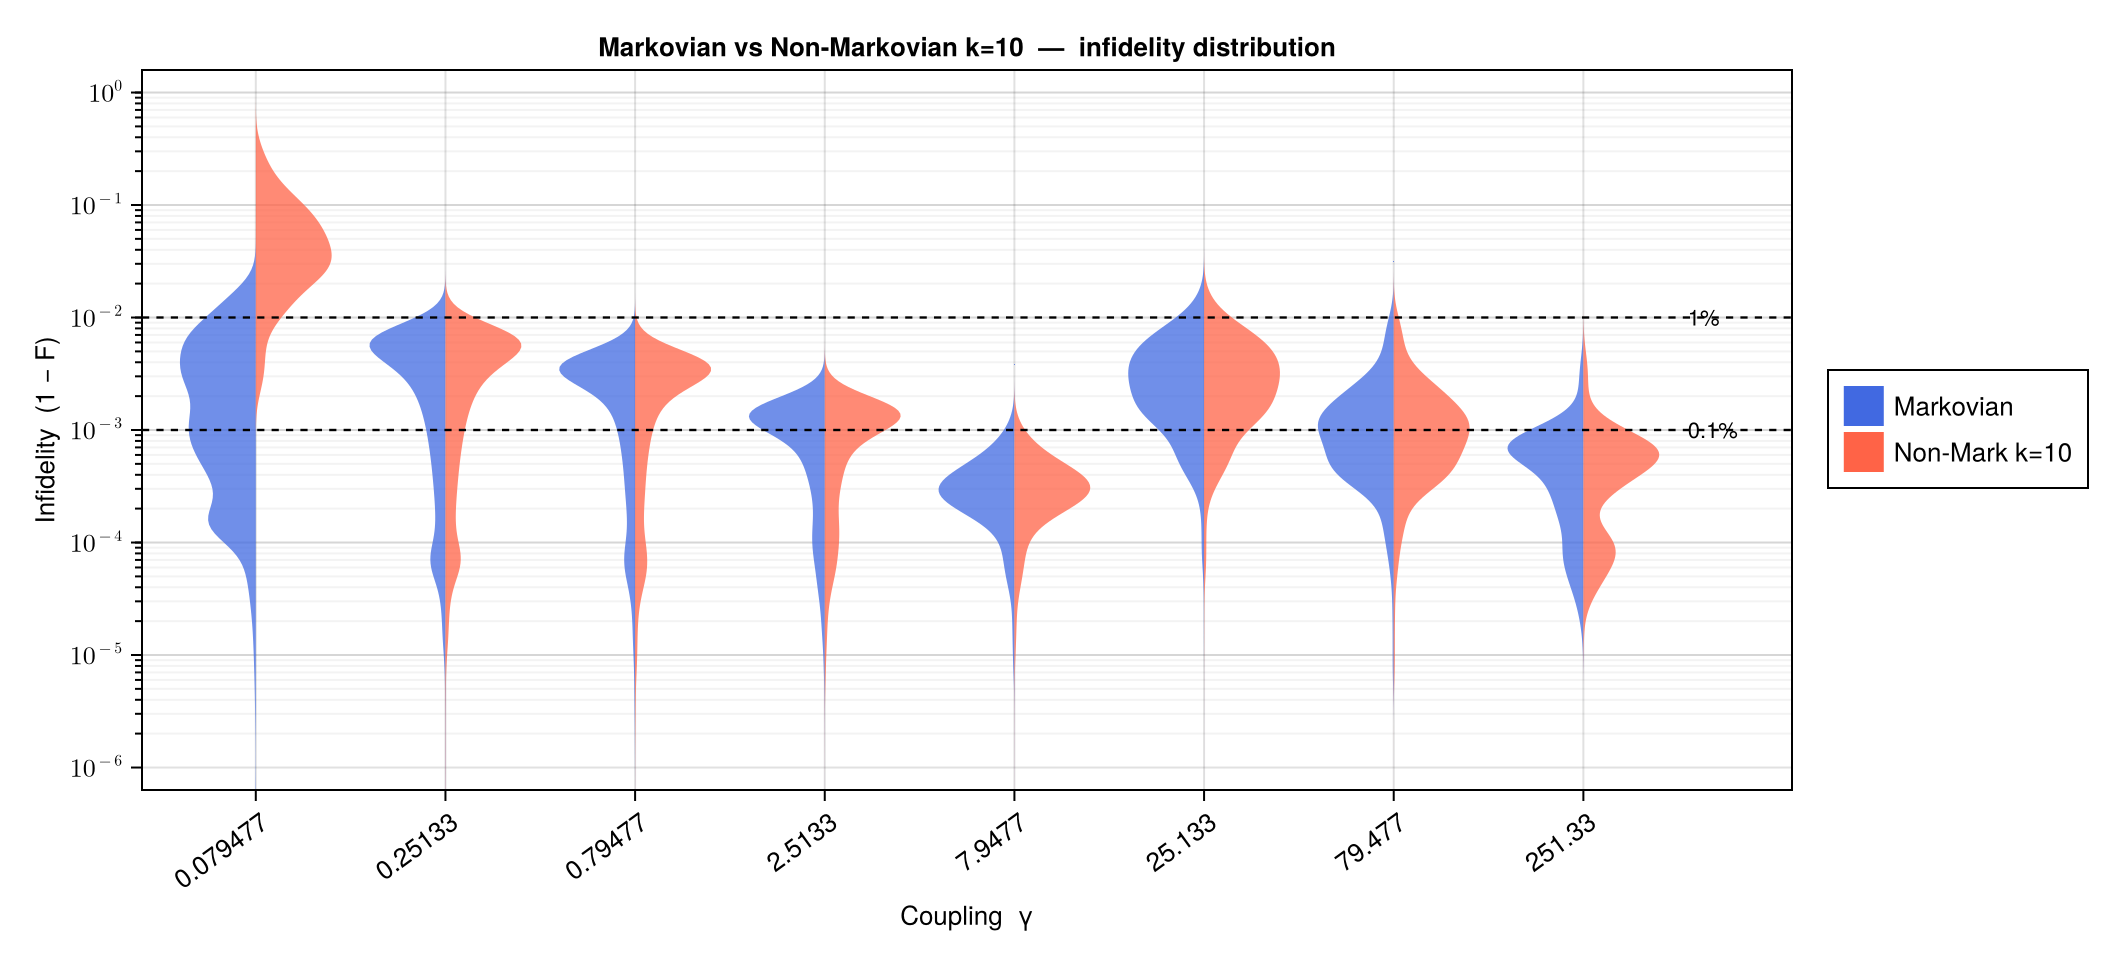

In [36]:
# ── Side-by-side violin plot: log infidelity per γ ───────────────────────────
# Left half of each violin = Markovian (blue), right half = Non-Markovian (red)

n = length(γ_values)
xs = 1:n   # integer positions on x axis

COLOR_M  = (:royalblue,   0.75)
COLOR_NM = (:tomato,      0.75)

fig = Figure(size=(180 + 110*n, 480), fontsize=13)
ax  = Axis(fig[1, 1],
    xlabel       = "Coupling  γ",
    ylabel       = "Infidelity  (1 − F)",
    title        = "Markovian vs Non-Markovian k=$k  —  infidelity distribution",
    xticks       = (xs, γ_values),
    xticklabelrotation = π/5,
)

for (i, γᵢ) in enumerate(γ_values)
    violin!(ax, fill(i, length(log_inf_mark[γᵢ])),    log_inf_mark[γᵢ];
            side=:left,  color=COLOR_M,  bandwidth=0.15, datalimits=(-10, 0))
    violin!(ax, fill(i, length(log_inf_nonmark[γᵢ])), log_inf_nonmark[γᵢ];
            side=:right, color=COLOR_NM, bandwidth=0.15, datalimits=(-10, 0))
end

# y axis: log scale ticks from 10^-6 to 10^0
ymin, ymax = -6.2, 0.2
ylims!(ax, ymin, ymax)
major_ticks  = collect(-6:0)
minor_ticks  = [log10(x) for p in -6:-1 for x in range(10.0^p, 10.0^(p+1); length=10)[2:end]]
ax.yticks    = (major_ticks, [L"10^{%$p}" for p in major_ticks])
ax.yminorticks = minor_ticks
ax.yminorgridvisible = true
ax.yminorticksvisible = true

# Reference lines at 1 % and 0.1 % infidelity
for (level, label) in [(0.01, "1%"), (0.001, "0.1%")]
    hlines!(ax, log10(level); color=:black, linestyle=:dash, linewidth=1.2)
    text!(ax, n + 0.55, log10(level); text=label, fontsize=11, align=(:left, :center))
end

xlims!(ax, 0.4, n + 1.1)

# Legend
elem_m  = [PolyElement(color=COLOR_M[1],  strokecolor=:transparent)]
elem_nm = [PolyElement(color=COLOR_NM[1], strokecolor=:transparent)]
Legend(fig[1, 2], [elem_m, elem_nm], ["Markovian", "Non-Mark k=$k"],
       framevisible=true, padding=(8,8,8,8))

violin_path = replace(out_file, ".h5" => "_violin.pdf")
save(violin_path, fig)
println("Saved: ", violin_path)
fig

Saved: ../TESTS/Mark_vs_NonMark_H0_k5_ALLGAMMA_2026-Apr-14_at_12-12_fidelity.pdf


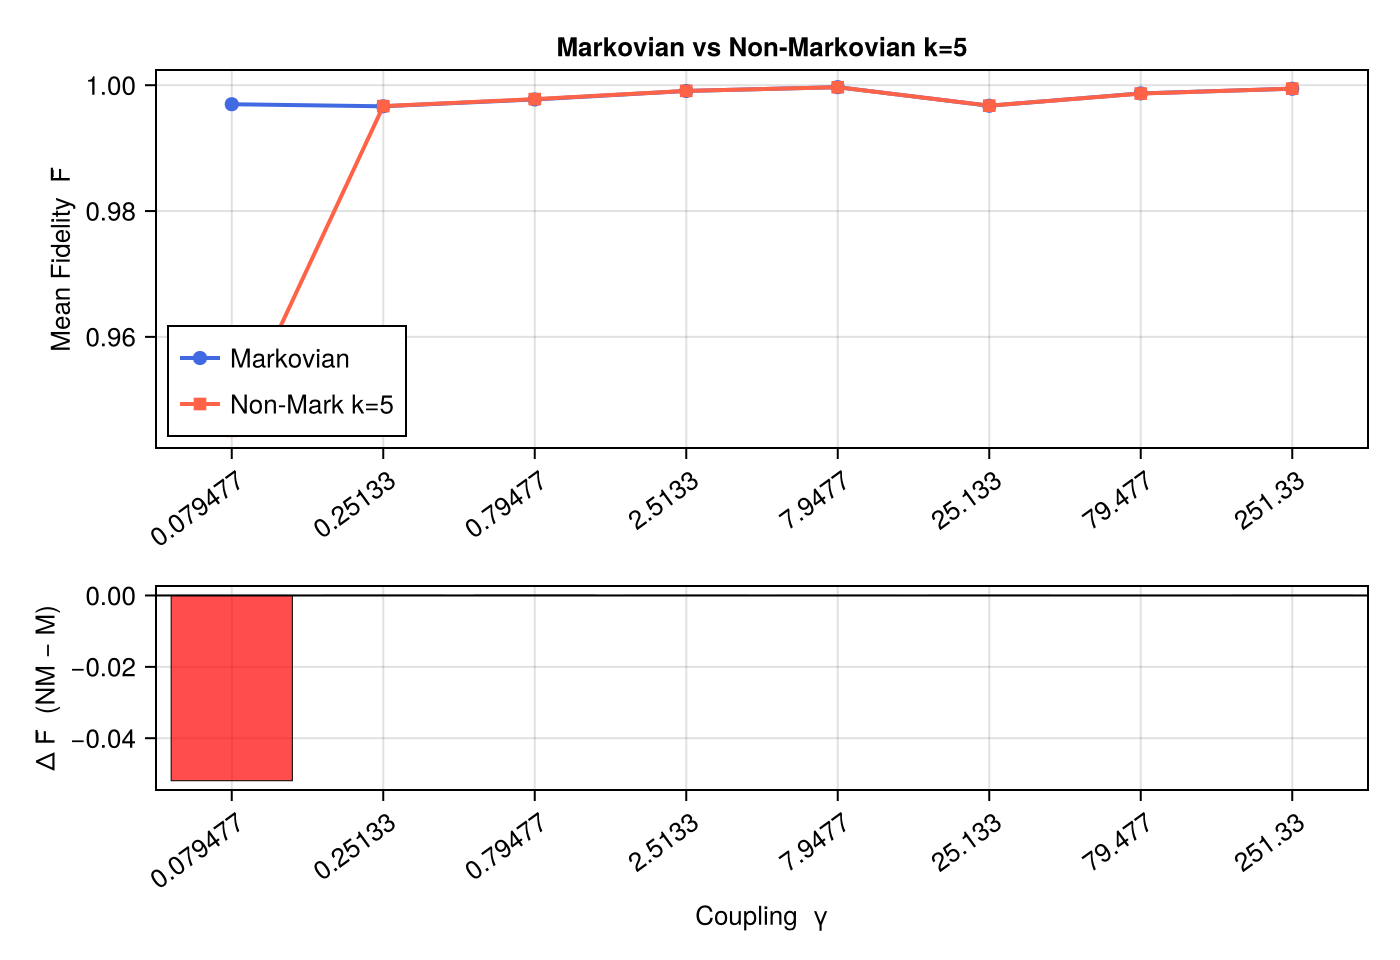

In [32]:
# ── Mean fidelity vs γ: connected scatter plot ───────────────────────────────

F_m_vals  = [F_mark_mean[γ]    for γ in γ_values]
F_nm_vals = [F_nonmark_mean[γ] for γ in γ_values]
Δ_vals    = F_nm_vals .- F_m_vals

fig2 = Figure(size=(700, 480), fontsize=13)

# Top panel: mean fidelity
ax_top = Axis(fig2[1, 1],
    ylabel = "Mean Fidelity  F̄",
    title  = "Markovian vs Non-Markovian k=$k",
    xticks = (xs, γ_values),
    xticklabelrotation = π/5,
)
scatterlines!(ax_top, xs, F_m_vals;  color=:royalblue, marker=:circle,  markersize=10, linewidth=2, label="Markovian")
scatterlines!(ax_top, xs, F_nm_vals; color=:tomato,    marker=:rect,    markersize=10, linewidth=2, label="Non-Mark k=$k")
axislegend(ax_top; position=:lb)
xlims!(ax_top, 0.5, n + 0.5)

# Bottom panel: improvement ΔF̄ = F̄_NM − F̄_M
ax_bot = Axis(fig2[2, 1],
    xlabel = "Coupling  γ",
    ylabel = "Δ F̄  (NM − M)",
    xticks = (xs, γ_values),
    xticklabelrotation = π/5,
)
barplot!(ax_bot, xs, Δ_vals;
    color = [Δ > 0 ? (:green, 0.7) : (:red, 0.7) for Δ in Δ_vals],
    strokewidth = 0.5, strokecolor = :black)
hlines!(ax_bot, 0.0; color=:black, linewidth=1)
xlims!(ax_bot, 0.5, n + 0.5)

rowsize!(fig2.layout, 1, Relative(0.65))

fidelity_path = replace(out_file, ".h5" => "_fidelity.pdf")
save(fidelity_path, fig2)
println("Saved: ", fidelity_path)
fig2